# M4 Assignment 2

Business Context:
The data is a marketing campaign data of a skin care clinic associated with its success.

Dataset Description

Success: Response to marketing campaign of Skin Care Clinic which offers both  products and services. (1: email Opened, 0: email not opened)

* AGE: Age Group of Customer
* Recency_Service: Number of days since last service purchase
* Recency_Product: Number of days since last product purchase
* Bill_Service: Total bill amount for service in last 3 months
* Bill_Product: Total bill amount for products in last 3 months
* Gender (1: Male, 2: Female)

Tasks

1. Import Email Campaign data. Obtain decision tree to classify cases as success=0 or 1. Obtain Sensitivity/Recall using cut-off value as 0.50 for estimated probabilities.
2. Compare performance of Decision Tree and Random Forest Method using area under the ROC curve.
3. Implement Neural Network Algorithm and obtain area under the ROC curve .

In [179]:
import pandas as pd

df = pd.read_csv("M4 Assignment 2 - Email Campaign.csv")
df.head()

,SN,Gender,AGE,Recency_Service,Recency_Product,Bill_Service,Bill_Product,Success
0,1,1,<=45,12,11,11.82,2.68,0
1,2,0,<=30,6,0,10.31,1.32,0
2,3,1,<=30,1,9,7.43,0.49,0
3,4,1,<=45,2,14,13.68,1.85,0
4,5,0,<=30,0,11,4.56,1.01,1


In [180]:
df.describe()

,SN,Gender,Recency_Service,Recency_Product,Bill_Service,Bill_Product,Success
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,342.000000,0.455344,8.471449,8.376281,10.795974,2.065476,0.263543
std,197.309402,0.498367,6.730919,6.952319,6.867534,2.166430,0.440877
min,1.000000,0.000000,0.000000,0.000000,0.450000,0.050000,0.000000
25%,171.500000,0.000000,3.000000,3.000000,5.705000,0.860000,0.000000
50%,342.000000,0.000000,7.000000,7.000000,9.280000,1.450000,0.000000
75%,512.500000,1.000000,12.500000,12.000000,14.835000,2.460000,1.000000
max,683.000000,1.000000,32.000000,35.000000,41.550000,20.690000,1.000000


In [181]:
df.isnull().sum()

SN                 0
Gender             0
AGE                0
Recency_Service    0
Recency_Product    0
Bill_Service       0
Bill_Product       0
Success            0
dtype: int64

In [182]:
df['Gender_Cat'] = df['Gender'].map({0: 'Male', 1: 'Female'}).astype('category')
df = df.reindex(columns=['SN', 'Gender', 'Gender_Cat', 'AGE', 'Recency_Service', 'Recency_Product', 'Bill_Service', 'Bill_Product', 'Success'])
df.head()

,SN,Gender,Gender_Cat,AGE,Recency_Service,Recency_Product,Bill_Service,Bill_Product,Success
0,1,1,Female,<=45,12,11,11.82,2.68,0
1,2,0,Male,<=30,6,0,10.31,1.32,0
2,3,1,Female,<=30,1,9,7.43,0.49,0
3,4,1,Female,<=45,2,14,13.68,1.85,0
4,5,0,Male,<=30,0,11,4.56,1.01,1


In [183]:
from sklearn.model_selection import train_test_split

# target == "Success"
X = df.drop(columns=["SN", "Gender", "Success"])
y = df["Success"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

## Decision Tree Model

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

# StandardScaler for numeric features is not needed for Trees, but it is useful for Neural Networks
preprocess = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown="ignore"), ['Gender_Cat', 'AGE']),
        ("num", StandardScaler(), ['Recency_Service', 'Recency_Product', 'Bill_Service', 'Bill_Product']),
    ],
    remainder="drop"
)

decision_tree_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender_Cat', 'AGE']),
                                                 ('num', StandardScaler(),
                                                  ['Recency_Service',
                                                   'Recency_Product',
                                                   'Bill_Service',
                                                   'Bill_Product'])])),
                ('clf', DecisionTreeClassifier(random_state=42))])

In [185]:
from sklearn.metrics import confusion_matrix, recall_score, classification_report, roc_auc_score, roc_curve

# Predicted probabilities for class 1
decision_tree_proba = decision_tree_model.predict_proba(X_test)[:, 1]

# Cutoff = 0.50
decision_tree_pred_050 = (decision_tree_proba >= 0.50).astype(int)

# Confusion matrix
decision_tree_confusion_matrix = confusion_matrix(y_test, decision_tree_pred_050)
print("DT - Confusion Matrix (cutoff 0.50):\n", decision_tree_confusion_matrix)

# Sensitivity / Recall for positive class (Success=1)
decision_tree_sensitivity = recall_score(y_test, decision_tree_pred_050, pos_label=1)
print("DT - Sensitivity/Recall @ 0.50:", decision_tree_sensitivity)

print("\nDT - Classification Report @ 0.50:\n", classification_report(y_test, decision_tree_pred_050, digits=4))

DT - Confusion Matrix (cutoff 0.50):
 [[128  23]
 [ 28  26]]
DT - Sensitivity/Recall @ 0.50: 0.48148148148148145

DT - Classification Report @ 0.50:
               precision    recall  f1-score   support

           0     0.8205    0.8477    0.8339       151
           1     0.5306    0.4815    0.5049        54

    accuracy                         0.7512       205
   macro avg     0.6756    0.6646    0.6694       205
weighted avg     0.7441    0.7512    0.7472       205



## Random Forest Model

In [186]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

random_forest_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        max_depth=None,
        min_samples_leaf=10,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

random_forest_proba = random_forest_model.predict_proba(X_test)[:, 1]

# Cutoff = 0.50
random_forest_pred_050 = (random_forest_proba >= 0.50).astype(int)

# Confusion matrix
random_forest_confusion_matrix = confusion_matrix(y_test, random_forest_pred_050)
print("RF - Confusion Matrix (cutoff 0.50):\n", random_forest_confusion_matrix)

# Sensitivity / Recall for positive class (Success=1)
random_forest_sensitivity = recall_score(y_test, random_forest_pred_050, pos_label=1)
print("RF - Sensitivity/Recall @ 0.50:", random_forest_sensitivity)

print("\nRF - Classification Report @ 0.50:\n", classification_report(y_test, random_forest_pred_050, digits=4))

RF - Confusion Matrix (cutoff 0.50):
 [[144   7]
 [ 36  18]]
RF - Sensitivity/Recall @ 0.50: 0.3333333333333333

RF - Classification Report @ 0.50:
               precision    recall  f1-score   support

           0     0.8000    0.9536    0.8701       151
           1     0.7200    0.3333    0.4557        54

    accuracy                         0.7902       205
   macro avg     0.7600    0.6435    0.6629       205
weighted avg     0.7789    0.7902    0.7609       205



## Comparison (DT vs RT)

Decision Tree AUC: 0.6645818003433897
Random Forest AUC: 0.7958057395143487


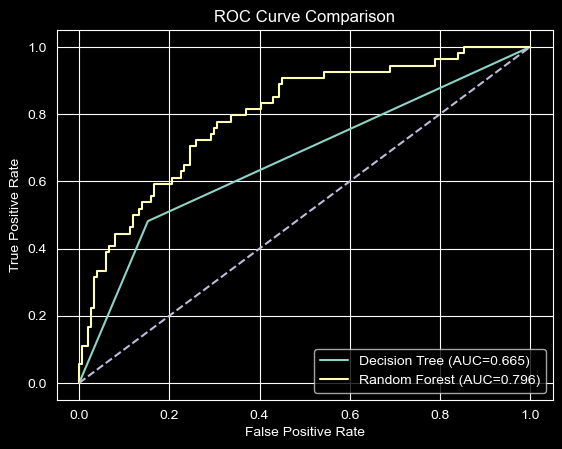

In [187]:
decision_tree_auc = roc_auc_score(y_test, decision_tree_proba)
random_forest_auc = roc_auc_score(y_test, random_forest_proba)

print("Decision Tree AUC:", decision_tree_auc)
print("Random Forest AUC:", random_forest_auc)

# Plot ROC curves
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_proba)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_proba)

plt.figure()
plt.plot(decision_tree_fpr, decision_tree_tpr, label=f"Decision Tree (AUC={decision_tree_auc:.3f})")
plt.plot(random_forest_fpr, random_forest_tpr, label=f"Random Forest (AUC={random_forest_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Neural Network

In [188]:
from sklearn.neural_network import MLPClassifier

neural_network_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=5e-4,
        max_iter=5000,
        early_stopping=True,
        random_state=42
    ))
])

neural_network_model.fit(X_train, y_train)

neural_network_proba = neural_network_model.predict_proba(X_test)[:, 1]
neural_network_auc = roc_auc_score(y_test, neural_network_proba)

print("Neural Network AUC:", neural_network_auc)

Neural Network AUC: 0.7564385577630611


## Comparison (NN vs DT vs RT)

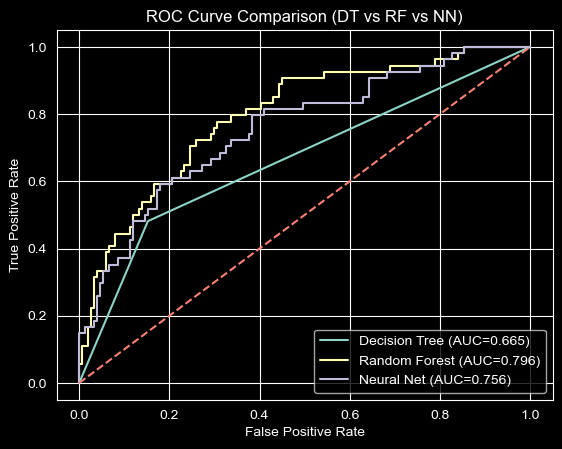

In [189]:
neural_network_fpr, neural_network_tpr, _ = roc_curve(y_test, neural_network_proba)

plt.figure()
plt.plot(decision_tree_fpr, decision_tree_tpr, label=f"Decision Tree (AUC={decision_tree_auc:.3f})")
plt.plot(random_forest_fpr, random_forest_tpr, label=f"Random Forest (AUC={random_forest_auc:.3f})")
plt.plot(neural_network_fpr, neural_network_tpr, label=f"Neural Net (AUC={neural_network_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (DT vs RF vs NN)")
plt.legend()
plt.show()

The ROC curve comparison shows that the Random Forest achieves the highest AUC, followed by the Neural Network and then the Decision Tree. This indicates that ensemble learning (Random Forest) provides better discrimination capability than a single tree model.

The Neural Network performs competitively, suggesting that non-linear relationships exist in the data; however, its performance does not surpass Random Forest, possibly due to the relatively small dataset size and limited feature complexity.

Overall, Random Forest appears to be the most robust model for predicting campaign success, as it balances variance reduction and predictive power.